# Transactions Exploratory Data Analysis

## Project: Customer Segmentation Analysis

This notebook explores the cleaned Transactions dataset to understand transaction patterns, product characteristics, pricing, order channels, and customer purchasing behaviour before RFM analysis and customer segmentation.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Configure display options

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
# Load dataset

transactions = pd.read_excel("Transactions_Cleaned.xlsx")

In [4]:
# Display the first five rows

transactions.head()

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
0,1293,67,1931,2017-01-01,1,Approved,Norco Bicycles,Road,medium,medium,544.05,376.84,2005-10-22
1,3525,50,3490,2017-01-01,1,Approved,Giant Bicycles,Standard,medium,medium,642.70,211.37,2002-03-22
2,12544,36,3062,2017-01-01,0,Approved,Solex,Standard,low,medium,945.04,507.58,1995-12-19
3,12485,85,2805,2017-01-01,1,Approved,WeareA2B,Standard,medium,medium,1228.07,400.91,2000-05-22
4,3518,58,523,2017-01-01,1,Approved,OHM Cycles,Standard,medium,medium,912.52,141.40,2015-05-21


## Dataset Overview

This section provides a general overview of the Transactions dataset, including its dimensions, structure, data types, and summary statistics.

In [5]:
# Display dataset dimensions

print(f"Number of rows: {transactions.shape[0]:,}")
print(f"Number of columns: {transactions.shape[1]}")

Number of rows: 19,803
Number of columns: 13


In [6]:
# Display column names

transactions.columns

Index(['transaction_id', 'product_id', 'customer_id', 'transaction_date',
       'online_order', 'order_status', 'brand', 'product_line',
       'product_class', 'product_size', 'list_price', 'standard_cost',
       'product_first_sold_date'],
      dtype='object')

In [7]:
# Display dataset information

transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19803 entries, 0 to 19802
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_id           19803 non-null  int64         
 1   product_id               19803 non-null  int64         
 2   customer_id              19803 non-null  int64         
 3   transaction_date         19803 non-null  datetime64[ns]
 4   online_order             19803 non-null  int64         
 5   order_status             19803 non-null  object        
 6   brand                    19803 non-null  object        
 7   product_line             19803 non-null  object        
 8   product_class            19803 non-null  object        
 9   product_size             19803 non-null  object        
 10  list_price               19803 non-null  float64       
 11  standard_cost            19803 non-null  float64       
 12  product_first_sold_date  19803 n

## Summary Statistics

This section summarises the numerical variables in the Transactions dataset to understand their central tendency, variability, and overall distribution.

In [8]:
# Display summary statistics for numerical variables

transactions.describe()

,transaction_id,product_id,customer_id,transaction_date,online_order,list_price,standard_cost,product_first_sold_date
count,19803.00,19803.00,19803.00,19803,19803.00,19803.00,19803.00,19803
mean,9993.98,45.82,1739.29,2017-07-01 15:40:43.811543808,0.47,1108.00,556.05,2004-07-31 18:38:13.834267392
min,1.00,0.00,1.00,2017-01-01 00:00:00,-1.00,12.01,7.21,1991-01-21 00:00:00
25%,4988.50,18.00,858.00,2017-04-01 00:00:00,0.00,575.27,215.14,1997-08-25 00:00:00
50%,9995.00,45.00,1738.00,2017-07-03 00:00:00,0.00,1163.89,507.58,2004-08-17 00:00:00
75%,15000.50,72.00,2615.00,2017-10-02 00:00:00,1.00,1635.30,795.10,2011-05-09 00:00:00
max,20000.00,100.00,5034.00,2017-12-30 00:00:00,1.00,2091.47,1759.85,2016-12-06 00:00:00
std,5776.50,30.57,1011.95,NaN,0.53,582.77,405.96,NaN


## Categorical Variables

This section summarises the categorical variables in the Transactions dataset by reporting the number of unique categories, the most frequent category, and its frequency.


In [9]:
# Display summary statistics for categorical variables

transactions.describe(include="object")

,order_status,brand,product_line,product_class,product_size
count,19803,19803,19803,19803,19803
unique,2,6,4,3,3
top,Approved,Solex,Standard,medium,medium
freq,19625,4253,14176,13826,12990


## Univariate Analysis

This section explores the distribution of individual variables in the Transactions dataset using descriptive statistics and visualisations to better understand transaction characteristics.

### Transaction Date

This section examines the distribution of transactions over time to identify overall transaction trends.

In [10]:
# Display transaction date range

print("Earliest transaction:", transactions["transaction_date"].min())
print("Latest transaction:", transactions["transaction_date"].max())

Earliest transaction: 2017-01-01 00:00:00
Latest transaction: 2017-12-30 00:00:00


In [11]:
# Number of transactions by month

monthly_transactions = (
    transactions
    .groupby(transactions["transaction_date"].dt.to_period("M"))
    .size()
)

monthly_transactions

,0
transaction_date,
2017-01,1665
2017-02,1612
2017-03,1629
2017-04,1641
2017-05,1666
2017-06,1564
2017-07,1700
2017-08,1735
2017-09,1559


#### Monthly Transaction Trend

The following line chart shows the number of transactions recorded each month throughout the observation period.

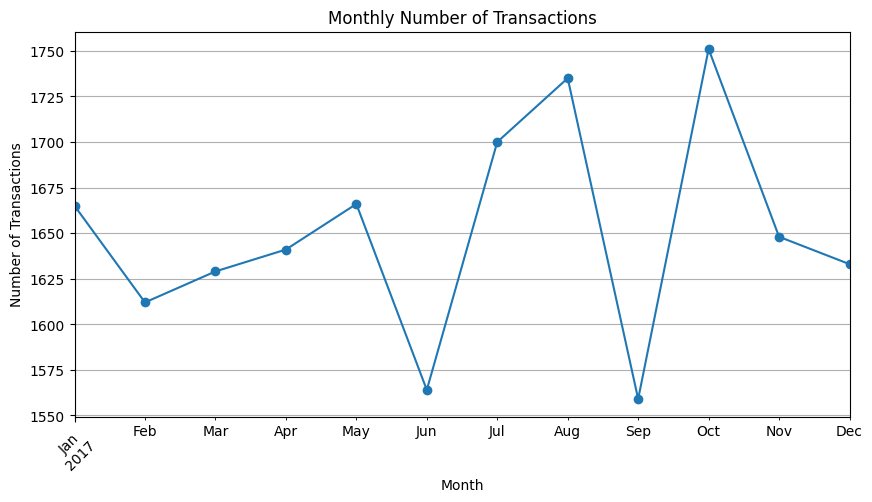

In [12]:
# Plot monthly transaction trend

monthly_transactions.plot(
    kind="line",
    figsize=(10, 5),
    marker="o"
)

plt.title("Monthly Number of Transactions")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

**Observation**

- The Transactions dataset contains records from **1 January 2017** to **30 December 2017**.
- Monthly transaction volumes remained relatively consistent throughout the year, ranging from **1,559** transactions (September) to **1,751** transactions (October).
- Although transaction counts fluctuate slightly between months, there is no clear long-term upward or downward trend across the observation period.

### Online Order

This section examines the distribution of online and offline orders to understand customer purchasing channels.

In [13]:
# Display online order frequency

transactions["online_order"].value_counts().sort_index()

,count
online_order,
-1,358
0,9706
1,9739


In [14]:
# Display online order percentage

transactions["online_order"].value_counts(normalize=True).sort_index().mul(100).round(2)

,proportion
online_order,
-1,1.81
0,49.01
1,49.18


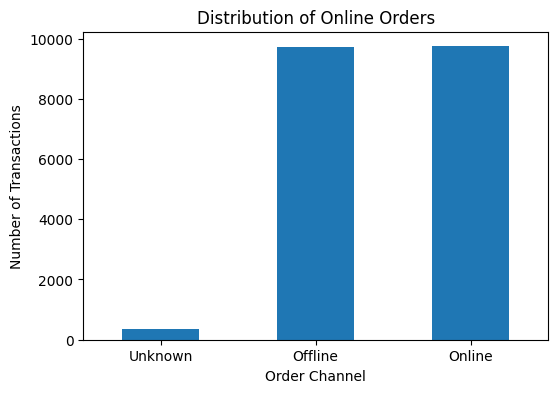

In [15]:
# Plot online order distribution

online_order_counts = transactions["online_order"].value_counts().sort_index()

online_order_counts.index = ["Unknown", "Offline", "Online"]

online_order_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Distribution of Online Orders")
plt.xlabel("Order Channel")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

**Observation**

- The distribution of online and offline orders is almost evenly balanced.
- Online orders account for **49.18%** (9,739 transactions), while offline orders account for **49.01%** (9,706 transactions).
- A small proportion of transactions (**1.81%**, 358 transactions) were recorded as **Unknown**, indicating that the order channel was unavailable or could not be determined during data preparation.

In [16]:
# Display order status frequency

transactions["order_status"].value_counts()

,count
order_status,
Approved,19625
Cancelled,178


In [17]:
# Display order status percentage

transactions["order_status"].value_counts(normalize=True).mul(100).round(2)

,proportion
order_status,
Approved,99.10
Cancelled,0.90


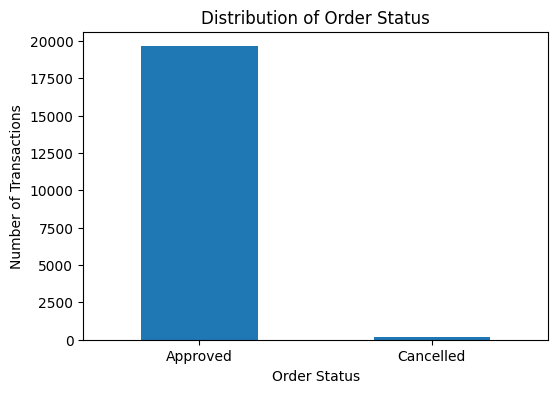

In [18]:
# Plot order status distribution

order_status_counts = transactions["order_status"].value_counts()

order_status_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

**Observation**

- The vast majority of transactions were **Approved**, accounting for **99.10%** (19,625 transactions).
- Only **0.90%** of transactions (178 transactions) were **Cancelled**.
- This indicates that nearly all recorded transactions were successfully completed, with only a very small proportion of cancelled orders.

### Brand

This section examines the distribution of bicycle brands purchased by customers to identify the most and least frequently purchased brands.

In [19]:
# Display brand frequency

transactions["brand"].value_counts()

,count
brand,
Solex,4253
Giant Bicycles,3312
WeareA2B,3295
OHM Cycles,3043
Trek Bicycles,2990
Norco Bicycles,2910


In [20]:
# Display brand percentage

transactions["brand"].value_counts(normalize=True).mul(100).round(2)

,proportion
brand,
Solex,21.48
Giant Bicycles,16.72
WeareA2B,16.64
OHM Cycles,15.37
Trek Bicycles,15.10
Norco Bicycles,14.69


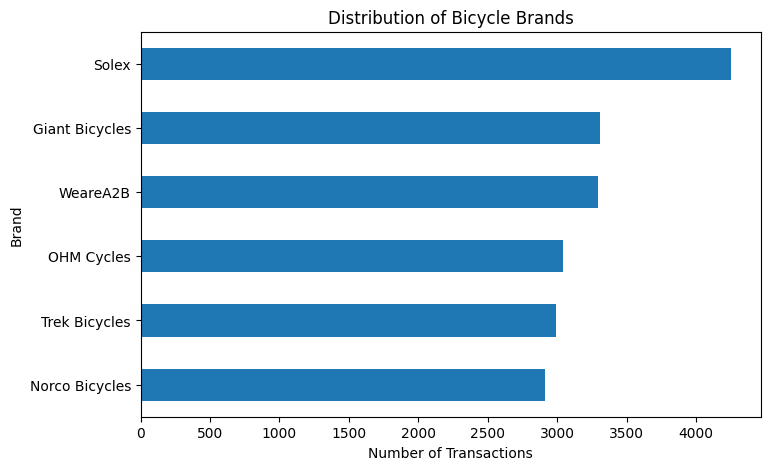

In [21]:
# Plot brand distribution

brand_counts = transactions["brand"].value_counts()

brand_counts.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Distribution of Bicycle Brands")
plt.xlabel("Number of Transactions")
plt.ylabel("Brand")

plt.show()

**Observation**

- **Solex** is the most frequently purchased brand, accounting for **21.48%** (4,253 transactions) of all recorded purchases.
- **Giant Bicycles** (16.72%) and **WeareA2B** (16.64%) are the next most frequently purchased brands.
- The remaining brands (**OHM Cycles**, **Trek Bicycles**, and **Norco Bicycles**) each contribute approximately **15%** of total transactions.
- Although Solex has the highest number of transactions, purchases are relatively well distributed across the six brands, with no single brand overwhelmingly dominating customer purchases.

### Product Line

This section examines the distribution of product lines purchased by customers to identify which categories contribute most to overall transactions.

In [22]:
# Display product line frequency

transactions["product_line"].value_counts()

,count
product_line,
Standard,14176
Road,3970
Touring,1234
Mountain,423


In [23]:
# Display product line percentage

transactions["product_line"].value_counts(normalize=True).mul(100).round(2)

,proportion
product_line,
Standard,71.59
Road,20.05
Touring,6.23
Mountain,2.14


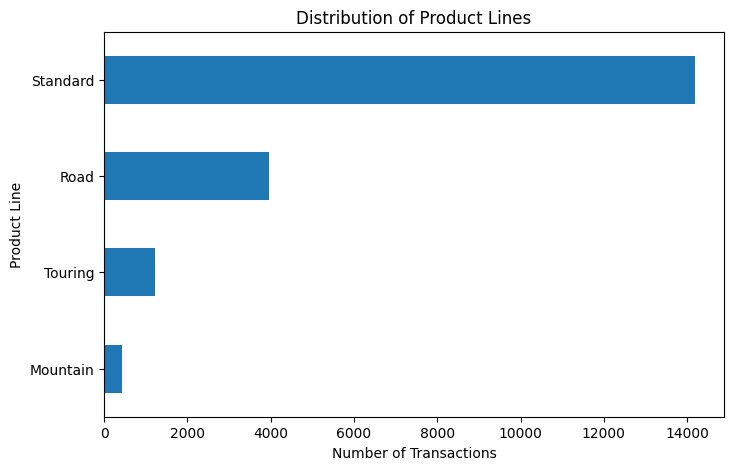

In [24]:
# Plot product line distribution

product_line_counts = transactions["product_line"].value_counts()

product_line_counts.sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

plt.title("Distribution of Product Lines")
plt.xlabel("Number of Transactions")
plt.ylabel("Product Line")

plt.show()

**Observation**

- The **Standard** product line is the most frequently purchased category, accounting for **71.59%** (14,176 transactions) of all recorded purchases.
- The **Road** product line is the second most popular, contributing **20.05%** (3,970 transactions).
- **Touring** (6.23%) and **Mountain** (2.14%) product lines account for a relatively small proportion of total transactions.
- The distribution indicates that customer purchases are heavily concentrated in the **Standard** product line, with substantially lower demand for the remaining product categories.

### Product Class

This section examines the distribution of product classes purchased by customers to understand customer preferences across different product categories.

In [25]:
# Display product class frequency

transactions["product_class"].value_counts()

,count
product_class,
medium,13826
high,3013
low,2964


In [26]:
# Display product class percentage

transactions["product_class"].value_counts(normalize=True).mul(100).round(2)

,proportion
product_class,
medium,69.82
high,15.21
low,14.97


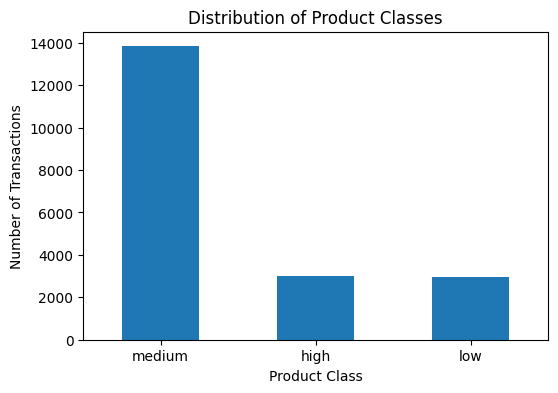

In [27]:
# Plot product class distribution

product_class_counts = transactions["product_class"].value_counts()

product_class_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Distribution of Product Classes")
plt.xlabel("Product Class")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

**Observation**

- The **medium** product class is the most frequently purchased category, accounting for **69.82%** (**13,826 transactions**) of all recorded purchases.
- The **high** (**15.21%**, **3,013 transactions**) and **low** (**14.97%**, **2,964 transactions**) product classes contribute similar proportions of total transactions.
- Customer purchases are therefore concentrated in **medium-class** products, while **high** and **low** product classes each represent approximately **15%** of purchases.
- This distribution suggests that customers generally prefer products in the **medium** price or specification segment, with comparatively lower demand for premium and entry-level products.

## Product Size

This section examines the distribution of product sizes purchased by customers to understand customer preferences across different product sizes.

In [28]:
# Display product size frequency

transactions["product_size"].value_counts()

,count
product_size,
medium,12990
large,3976
small,2837


In [29]:
# Display product size percentage

transactions["product_size"].value_counts(normalize=True).mul(100).round(2)

,proportion
product_size,
medium,65.60
large,20.08
small,14.33


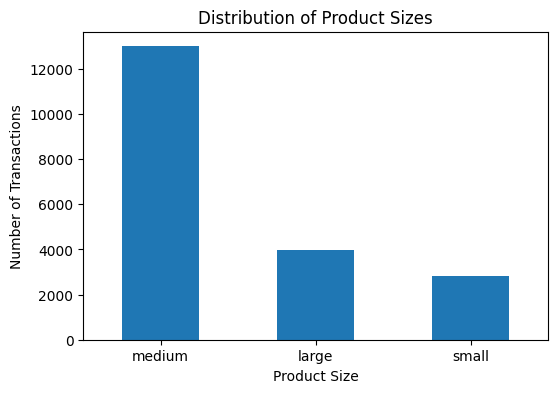

In [30]:
# Plot product size distribution

product_size_counts = transactions["product_size"].value_counts()

product_size_counts.plot(
    kind="bar",
    figsize=(6, 4)
)

plt.title("Distribution of Product Sizes")
plt.xlabel("Product Size")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

**Observation**

- The **medium** product size is the most frequently purchased category, accounting for **65.60%** (**12,990 transactions**) of all recorded purchases.
- The **large** product size is the second most common, representing **20.08%** (**3,976 transactions**).
- The **small** product size accounts for **14.33%** (**2,837 transactions**) of total purchases.
- Overall, customer purchases are concentrated in **medium-sized** products, indicating a clear preference for this product size over **large** and **small** alternatives.

## List Price

This section examines the distribution of product list prices using descriptive statistics and visualisations to understand pricing patterns, variability, and potential outliers.

In [31]:
# Display summary statistics for list price

transactions["list_price"].describe()

,list_price
count,19803.00
mean,1108.00
std,582.77
min,12.01
25%,575.27
50%,1163.89
75%,1635.30
max,2091.47


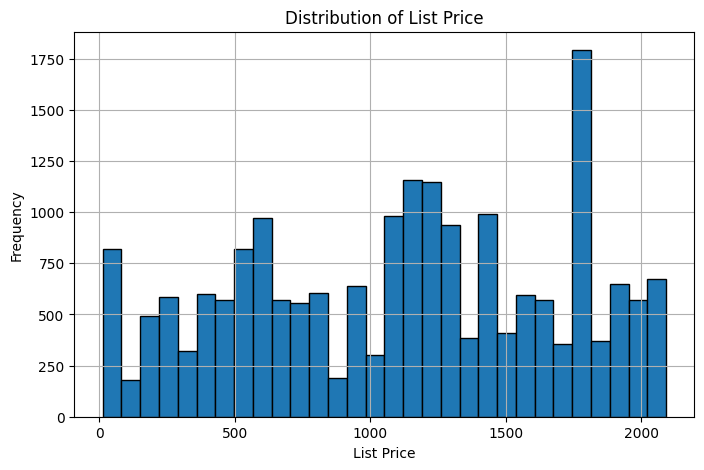

In [32]:
# Plot histogram of list price

plt.figure(figsize=(8, 5))

plt.hist(
    transactions["list_price"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of List Price")
plt.xlabel("List Price")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

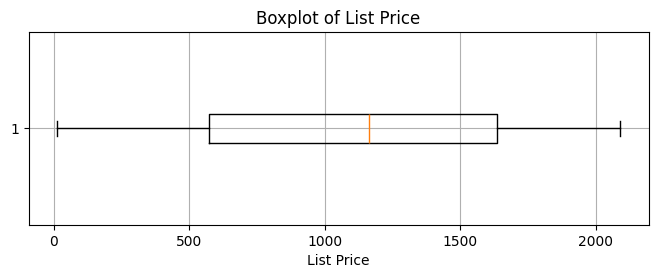

In [33]:
# Plot boxplot of list price

plt.figure(figsize=(8, 2.5))

plt.boxplot(
    transactions["list_price"],
    vert=False
)

plt.title("Boxplot of List Price")
plt.xlabel("List Price")

plt.grid(True)

plt.show()

**Observation**

- Product list prices range from **AUD 12.01** to **AUD 2,091.47**, indicating considerable variation in product pricing.
- The average list price is **AUD 1,108.00**, while the median is **AUD 1,163.89**, suggesting a slightly **left-skewed** distribution.
- The middle 50% of products have list prices between **AUD 575.27** and **AUD 1,635.30**, demonstrating a broad spread of prices across the product range.
- The histogram indicates that list prices are **not normally distributed**, with transactions concentrated around several pricing tiers rather than a single continuous peak.
- The boxplot does not indicate any obvious outliers, suggesting that the observed price range is consistent with the overall product portfolio.

## Standard Cost

This section examines the distribution of product standard costs.

Descriptive statistics and visualisations are used to understand cost patterns, variability, and potential outliers.

In [34]:
# Display summary statistics for standard cost

transactions["standard_cost"].describe()

,standard_cost
count,19803.00
mean,556.05
std,405.96
min,7.21
25%,215.14
50%,507.58
75%,795.10
max,1759.85


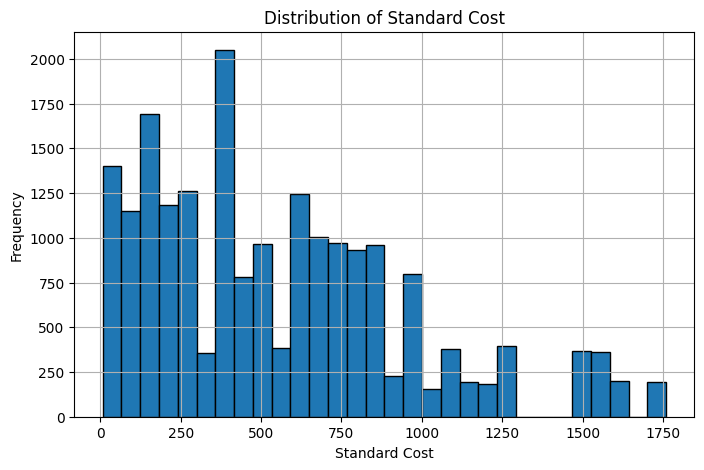

In [35]:
# Plot histogram of standard cost

plt.figure(figsize=(8,5))

plt.hist(
    transactions["standard_cost"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Standard Cost")
plt.xlabel("Standard Cost")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

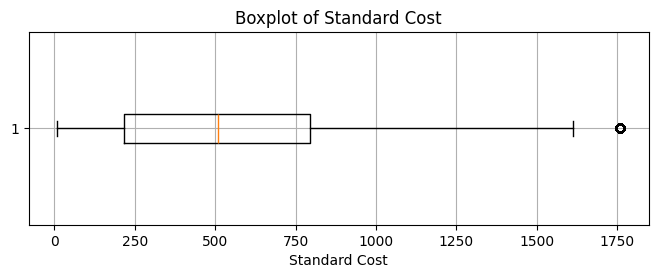

In [36]:
# Plot boxplot of standard cost

plt.figure(figsize=(8,2.5))

plt.boxplot(
    transactions["standard_cost"],
    vert=False
)

plt.title("Boxplot of Standard Cost")
plt.xlabel("Standard Cost")

plt.grid(True)

plt.show()

**Observation**

- Product standard costs range from **AUD 7.21** to **AUD 1,759.85**, indicating substantial variation in production costs across products.
- The average standard cost is **AUD 556.05**, while the median is **AUD 507.58**, suggesting a **slightly right-skewed** distribution.
- The middle 50% of products have standard costs between **AUD 215.14** and **AUD 795.10**, demonstrating considerable variability in production costs.
- The histogram indicates that standard costs are **not normally distributed**, with transactions concentrated around several cost levels rather than a single continuous peak.
- The boxplot shows **one potential high-cost outlier** above the upper whisker, indicating that a very small number of products have unusually high standard costs compared with the rest of the product portfolio.

## Profit Margin

This section examines the distribution of product profit margins.

Profit margins are calculated as the difference between list price and standard cost to understand profitability across products.

In [37]:
# Create profit margin

transactions["profit_margin"] = (
    transactions["list_price"] -
    transactions["standard_cost"]
)

In [38]:
# Display summary statistics for profit margin

transactions["profit_margin"].describe()

,profit_margin
count,19803.00
mean,551.95
std,493.41
min,4.80
25%,133.78
50%,445.21
75%,830.24
max,1702.55


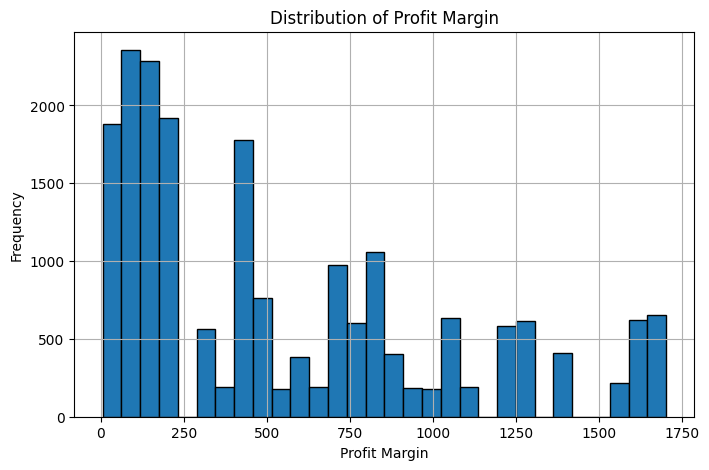

In [39]:
# Plot histogram of profit margin

plt.figure(figsize=(8,5))

plt.hist(
    transactions["profit_margin"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Profit Margin")
plt.xlabel("Profit Margin")
plt.ylabel("Frequency")

plt.grid(True)

plt.show()

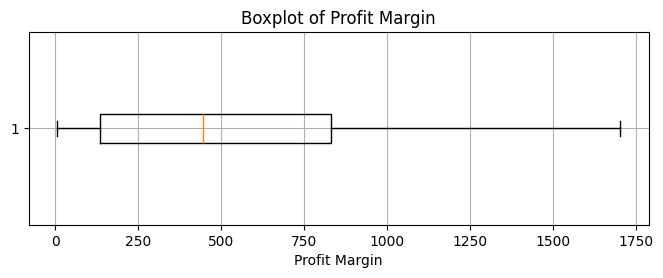

In [40]:
# Plot boxplot of profit margin

plt.figure(figsize=(8,2.5))

plt.boxplot(
    transactions["profit_margin"],
    vert=False
)

plt.title("Boxplot of Profit Margin")
plt.xlabel("Profit Margin")

plt.grid(True)

plt.show()

**Observation**

- Product profit margins range from **AUD 4.80** to **AUD 1,702.55**, indicating substantial variation in profitability across products.
- The average profit margin is **AUD 551.95**, while the median is **AUD 445.21**, suggesting a **moderately right-skewed** distribution.
- The middle 50% of products have profit margins between **AUD 133.78** and **AUD 830.24**, demonstrating considerable variation in product profitability.
- The histogram indicates that profit margins are **not normally distributed**, with transactions concentrated around several profitability levels rather than a single continuous peak.
- The boxplot does **not indicate any obvious outliers**, suggesting that profit margins are generally consistent with the overall product portfolio despite the wide range of values.

## Monthly Sales

This section examines transaction activity across different months.

Monthly transaction volumes are analysed to identify seasonal purchasing patterns throughout the year.

In [42]:
# Display monthly transaction frequency

transactions["transaction_date"].dt.month_name().value_counts().reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
])

,count
transaction_date,
January,1665
February,1612
March,1629
April,1641
May,1666
June,1564
July,1700
August,1735
September,1559


In [43]:
# Display monthly transaction percentage

transactions["transaction_date"].dt.month_name().value_counts(normalize=True).mul(100).reindex([
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]).round(2)

,proportion
transaction_date,
January,8.41
February,8.14
March,8.23
April,8.29
May,8.41
June,7.90
July,8.58
August,8.76
September,7.87


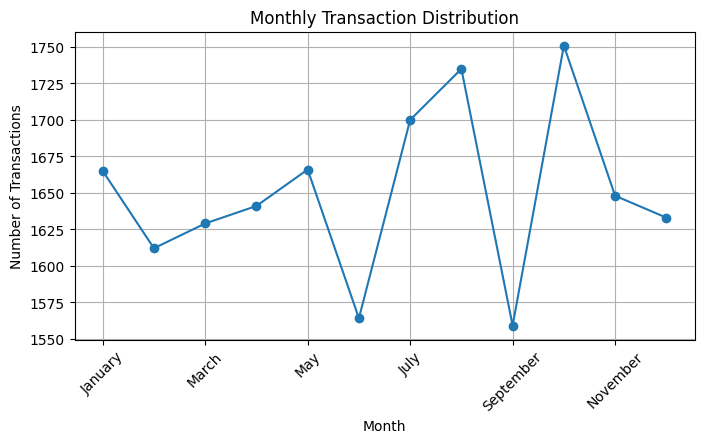

In [44]:
# Plot monthly transaction distribution

monthly_counts = (
    transactions["transaction_date"]
    .dt.month_name()
    .value_counts()
    .reindex([
        "January","February","March","April","May","June",
        "July","August","September","October","November","December"
    ])
)

monthly_counts.plot(
    kind="line",
    marker="o",
    figsize=(8,4)
)

plt.title("Monthly Transaction Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

**Observation**

- Monthly transaction volumes are relatively stable throughout the year, with each month contributing approximately **8%** of total transactions.
- **October** records the highest number of transactions, accounting for **8.84% (1,751 transactions)**, followed by **August (8.76%, 1,735 transactions)** and **July (8.58%, 1,700 transactions)**.
- **September** has the lowest transaction volume, representing **7.87% (1,559 transactions)**, closely followed by **June (7.90%, 1,564 transactions)**.
- The line chart indicates only minor fluctuations in monthly transaction activity, with no strong evidence of seasonal purchasing patterns.
- Overall, customer purchasing behaviour appears to be relatively consistent throughout the year, suggesting stable demand rather than pronounced seasonal peaks.

## Day of Week

This section examines transaction activity across different days of the week.

Daily transaction volumes are analysed to identify purchasing patterns and determine whether customers are more active on particular days.

In [45]:
# Display day of week transaction frequency

transactions["transaction_date"].dt.day_name().value_counts().reindex([
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
])

,count
transaction_date,
Monday,2852
Tuesday,2820
Wednesday,2883
Thursday,2782
Friday,2780
Saturday,2821
Sunday,2865


In [46]:
# Display day of week transaction percentage

transactions["transaction_date"].dt.day_name().value_counts(normalize=True).mul(100).reindex([
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]).round(2)

,proportion
transaction_date,
Monday,14.40
Tuesday,14.24
Wednesday,14.56
Thursday,14.05
Friday,14.04
Saturday,14.25
Sunday,14.47


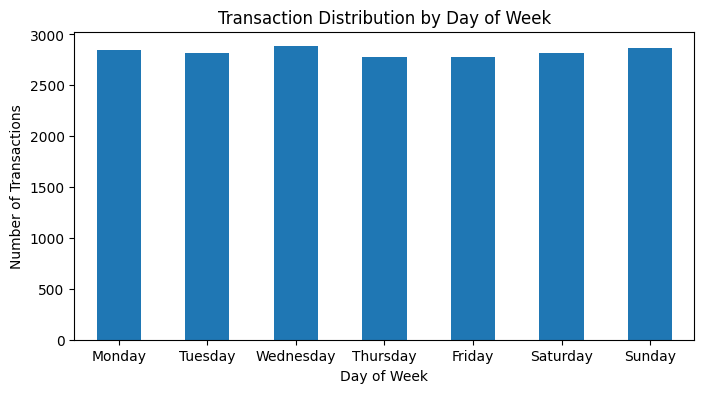

In [47]:
# Plot day of week transaction distribution

daily_counts = transactions["transaction_date"].dt.day_name().value_counts().reindex([
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
])

daily_counts.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Transaction Distribution by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.show()

**Observation**

- Transaction volumes are distributed relatively evenly across all seven days of the week, with each day contributing approximately **14%** of total transactions.
- **Wednesday** records the highest transaction volume, accounting for **14.56% (2,883 transactions)**, closely followed by **Sunday (14.47%, 2,865 transactions)** and **Monday (14.40%, 2,852 transactions)**.
- **Friday** has the lowest transaction volume, representing **14.04% (2,780 transactions)**, although the difference compared with other days is minimal.
- The bar chart shows only minor variation in daily transaction activity, with no clear weekday or weekend purchasing pattern.
- Overall, customer purchasing behaviour appears to be consistent throughout the week, suggesting that demand is stable regardless of the day.

## Overall Summary

This exploratory data analysis examined transaction patterns, product characteristics, pricing, profitability, and temporal purchasing behaviour.

Key findings include:

- The dataset contains **19,803 completed transactions** with no significant issues affecting the variables analysed.
- Customer purchases are relatively evenly distributed across the six bicycle brands, although **Solex** records the highest transaction volume.
- The **Standard** product line dominates sales, accounting for more than **70%** of all transactions, while **Road**, **Touring**, and **Mountain** products contribute substantially smaller proportions.
- Most purchases involve **medium** product classes and **medium-sized** products, indicating stronger demand for mid-range products than premium or entry-level alternatives.
- Product pricing varies considerably, with list prices ranging from approximately **AUD 12** to **AUD 2,091**. Pricing is not normally distributed and reflects multiple pricing tiers across the product portfolio.
- Standard costs also exhibit substantial variability and include a small number of unusually high-cost products.
- Profit margins vary across products, demonstrating considerable differences in profitability throughout the portfolio.
- Transaction activity remains relatively consistent throughout the year and across all days of the week, providing little evidence of strong seasonal or weekday purchasing patterns.

Overall, the transaction dataset indicates stable purchasing behaviour, broad product pricing and profitability, and customer preferences concentrated in mid-range product offerings. These findings provide a strong foundation for subsequent customer-level analysis and segmentation.